In [1]:
import treedata
from geomloss import SamplesLoss
import numpy as np
import networkx as nx
from geomloss import SamplesLoss
from collections import defaultdict
from tqdm.notebook import tqdm
import torch
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import scanpy as sc

/orcd/home/002/gokulg/miniforge3/envs/lineage/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/orcd/home/002/gokulg/miniforge3/envs/lineage/lib/python3.11/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/orcd/home/002/gokulg/miniforge3/envs/lineage/lib/python3.11/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


In [2]:
adata = treedata.read_h5td('/home/gokulg/orcd/scratch/lt/data/kl0.0_d50_l2_covnocov_adata_with_embeddings.h5ad')

In [3]:
tree_filenames = []
for e in ["7.5", "8.0", "8.5", "9.0", "9.5"]:
    for r in [1, 2, 3]:
        tree_filenames.append(f"e{e}_r{r}_tree")
tree_filenames.append("e10.0_r1_tree")

tdatas = [
    treedata.read_h5td(f"/home/gokulg/orcd/scratch/lt/data/embryos/{f}.h5td")
    for f in tree_filenames
]

trees, tree_names = [], []
for td in tdatas:
    for k in td.obst.keys():
        trees.append(td.obst[k])
        tree_names.append(k)

In [4]:


# Create name->index mapping
name_to_idx = {name: idx for idx, name in enumerate(adata.obs_names)}

# get state variables as numpy array for fast indexing
states = adata.obsm['X_scvi']

# MMD with energy kernel
mmd_loss = SamplesLoss("energy")

# get all leaves
leaves = []
for tree in trees:
    leaves.extend([node for node in tree.nodes() if tree.out_degree(node) == 0 and node in name_to_idx])

# precompute descendants for each node (cache to avoid recomputation)
descendants_cache = {}

def get_leaf_descendants(node, tree):
    """Get all leaf descendants of a node."""
    if node in descendants_cache:
        return descendants_cache[node]
    
    if tree.out_degree(node) == 0:  # node is a leaf
        result = {node}
    else:
        result = set()
        for descendant in nx.descendants(tree, node):
            if tree.out_degree(descendant) == 0:
                result.add(descendant)
    
    descendants_cache[node] = result
    return result

##################
# subsample for MMD reference distribution
##################
n_subsample = 100
##################
##################

# get all leaf indices and subsample once
all_leaf_indices = np.array([name_to_idx[leaf] for leaf in leaves])
all_leaf_states = states[all_leaf_indices]

# subsample all leaf states
if len(all_leaf_states) > n_subsample:
    subsample_idx = np.random.choice(len(all_leaf_states), n_subsample, replace=False)
    all_leaf_states_subsampled = all_leaf_states[subsample_idx]
else:
    all_leaf_states_subsampled = all_leaf_states

all_leaf_states_tensor = torch.from_numpy(all_leaf_states_subsampled).float()

In [5]:
# Compute MMD once per node
node_mmd = {}

for tree, name in tqdm(zip(trees, tree_names), desc="processing trees", total=len(trees)):

    nodes = tree.nodes()

    for node in tqdm(nodes, desc="computing MMD per node", leave=False):

        # get descendant leaves of this node
        descendant_leaves = get_leaf_descendants(node, tree)
        
        # get their indices and states
        descendant_indices = np.array([name_to_idx[l] for l in descendant_leaves if l in name_to_idx])

        if descendant_indices.size == 0:
            # print(f"Node {node} has no descendant leaves in the dataset, skipping MMD computation.")
            continue

        descendant_states = states[descendant_indices]
        
        # subsample descendant states
        if len(descendant_states) > n_subsample:
            subsample_idx = np.random.choice(len(descendant_states), n_subsample, replace=False)
            descendant_states_subsampled = descendant_states[subsample_idx]
        else:
            descendant_states_subsampled = descendant_states
        
        descendant_states_tensor = torch.from_numpy(descendant_states_subsampled).float()
        
        # compute MMD between entire population and descendant leaves
        mmd_value = mmd_loss(all_leaf_states_tensor, descendant_states_tensor).item()
        
        # get time attribute if it exists
        node_time = tree.nodes[node].get('time', None)
        
        node_mmd[node] = (mmd_value, node_time)



processing trees:   0%|          | 0/56 [00:00<?, ?it/s]

computing MMD per node:   0%|          | 0/1487 [00:00<?, ?it/s]

Node E7.5-R1-T1-TGAGGCAAGGTCGAGA-1 has no descendant leaves in the dataset, skipping MMD computation.


computing MMD per node:   0%|          | 0/302 [00:00<?, ?it/s]

computing MMD per node:   0%|          | 0/1356 [00:00<?, ?it/s]

...

Node E10.0-R1-T3-CCTCACGCACTAGGCA-1 has no descendant leaves in the dataset, skipping MMD computation.
Node E10.0-R1-T9-CTAAGGCTCGCGATTA-1 has no descendant leaves in the dataset, skipping MMD computation.
Node E10.0-R1-T2-TGTCTGTTCACAGCCG-1 has no descendant leaves in the dataset, skipping MMD computation.
Node E10.0-R1-T4-GGGATCAAGCTATCTC-1 has no descendant leaves in the dataset, skipping MMD computation.
Node E10.0-R1-T17-TCACACCCATGACGGC-1 has no descendant leaves in the dataset, skipping MMD computation.
Node E10.0-R1-T6-GGCAATTCAAGCGCAC-1 has no descendant leaves in the dataset, skipping MMD computation.
Node E10.0-R1-T4-ATCGCGCGTCTTACCC-1 has no descendant leaves in the dataset, skipping MMD computation.
Node E10.0-R1-T12-ATGTGTTAGCCCTGGA-1 has no descendant leaves in the dataset, skipping MMD computation.
Node E10.0-R1-T2-GGTGGCAGTGAGCGTG-1 has no descendant leaves in the dataset, skipping MMD computation.
Node E10.0-R1-T16-ACCCATCCAGCACGGT-1 has no descendant leaves in the da

computing MMD per node:   0%|          | 0/14151 [00:00<?, ?it/s]

Node E10.0-R1-T2-GCTTAACGTTGCGTAT-1 has no descendant leaves in the dataset, skipping MMD computation.
Node cpSxCP41 has no descendant leaves in the dataset, skipping MMD computation.
Node E10.0-R1-T5-ACTCACTTCGCGAACT-1 has no descendant leaves in the dataset, skipping MMD computation.
Node E10.0-R1-T5-CTGTGGACACAGCATG-1 has no descendant leaves in the dataset, skipping MMD computation.
Node E10.0-R1-T11-AGAATAGTCGATGTAT-1 has no descendant leaves in the dataset, skipping MMD computation.
Node E10.0-R1-T7-ACTCAGGCAATTCGGG-1 has no descendant leaves in the dataset, skipping MMD computation.
Node E10.0-R1-T3-GGTTGGTTCGTGAATT-1 has no descendant leaves in the dataset, skipping MMD computation.
Node oBNlz8Le has no descendant leaves in the dataset, skipping MMD computation.
Node E10.0-R1-T14-AACGCGCCATAGGGCC-1 has no descendant leaves in the dataset, skipping MMD computation.
Node E10.0-R1-T14-TAATGAGAGTTACCCT-1 has no descendant leaves in the dataset, skipping MMD computation.
Node E10.0-

computing MMD per node:   0%|          | 0/8174 [00:00<?, ?it/s]

Node E10.0-R1-T12-CGCTGATAGTAAGGAC-1 has no descendant leaves in the dataset, skipping MMD computation.
Node E10.0-R1-T5-AGCACTTGTGAGTTGA-1 has no descendant leaves in the dataset, skipping MMD computation.
Node E10.0-R1-T12-CCCGCATTCGCTCTAT-1 has no descendant leaves in the dataset, skipping MMD computation.
Node E10.0-R1-T4-TCACCGCTCTAGCGCG-1 has no descendant leaves in the dataset, skipping MMD computation.
Node 1THqZgf5 has no descendant leaves in the dataset, skipping MMD computation.
Node E10.0-R1-T14-ACAGGTAGTTTGATTG-1 has no descendant leaves in the dataset, skipping MMD computation.
Node E10.0-R1-T14-CACCTATTCACGCATA-1 has no descendant leaves in the dataset, skipping MMD computation.
Node E10.0-R1-T17-CTAACGATCGTCTACT-1 has no descendant leaves in the dataset, skipping MMD computation.
Node E10.0-R1-T20-GTAACCCAGTTGGACC-1 has no descendant leaves in the dataset, skipping MMD computation.
Node E10.0-R1-T2-CTACGTAAGGTACTTG-1 has no descendant leaves in the dataset, skipping MMD

In [6]:
results = {}

for tree in tqdm(trees, desc="aggregating MMD results for leaves", total=len(trees)):
    leaves_in_tree = [node for node in tree.nodes() if tree.out_degree(node) == 0 and node in name_to_idx]
    for leaf in tqdm(leaves_in_tree, desc="processing leaves", leave=False):
        if leaf not in node_mmd:
            continue
        mmd_list = [node_mmd[leaf]]  # include leaf's own MMD
        
        # walk up the tree from leaf to root
        current = leaf
        
        # for each ancestor, look up the precomputed MMD
        while list(tree.predecessors(current)):
            parent = list(tree.predecessors(current))[0]
            if parent in node_mmd:
                mmd_list.append(node_mmd[parent])
            current = parent
        
        results[leaf] = mmd_list

aggregating MMD results for leaves:   0%|          | 0/56 [00:00<?, ?it/s]

processing leaves:   0%|          | 0/850 [00:00<?, ?it/s]

processing leaves:   0%|          | 0/181 [00:00<?, ?it/s]

processing leaves:   0%|          | 0/766 [00:00<?, ?it/s]

processing leaves:   0%|          | 0/199 [00:00<?, ?it/s]

...

processing leaves:   0%|          | 0/86064 [00:00<?, ?it/s]

processing leaves:   0%|          | 0/49189 [00:00<?, ?it/s]

processing leaves:   0%|          | 0/11966 [00:00<?, ?it/s]

processing leaves:   0%|          | 0/9587 [00:00<?, ?it/s]

processing leaves:   0%|          | 0/5467 [00:00<?, ?it/s]

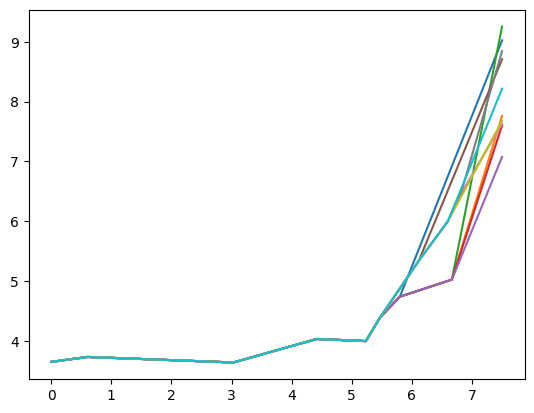

In [7]:
# now generate a plot of mmd trajectories per leaf, for 10 random leaves
import matplotlib.pyplot as plt
import random

random_leaves = leaves[:10]
for leaf in random_leaves:
    if leaf not in results:
        print(f"Leaf {leaf} has no MMD results, skipping plot.")
        continue
    mmd_values, times = zip(*results[leaf])
    plt.plot(times, mmd_values, label=leaf)

In [8]:


# Compute t_threshold for each leaf trajectory
import pandas as pd

# Define threshold as fraction of maximum MMD
threshold_fraction = 0.9

t_threshold_values = []

for leaf in tqdm(adata.obs_names, desc=f"Computing t_{threshold_fraction}"):

    if leaf not in results:
        # If no MMD results for this leaf, set to NaN
        t_threshold_values.append(np.nan)
        continue

    trajectory = results[leaf]
    
    if not trajectory:
        # If no trajectory, set to NaN
        t_threshold_values.append(np.nan)
        continue
    
    mmd_values, times = zip(*trajectory)
    mmd_values = np.array(mmd_values)
    times = np.array(times)
    
    # Find maximum MMD
    max_mmd = np.max(mmd_values)
    
    # Compute threshold
    threshold = threshold_fraction * max_mmd
    
    # Find first time when MMD exceeds threshold
    # Sort by time to ensure we find the earliest occurrence
    sort_idx = np.argsort(times)
    times_sorted = times[sort_idx]
    mmd_sorted = mmd_values[sort_idx]
    
    exceeds_threshold = mmd_sorted >= threshold
    
    if np.any(exceeds_threshold):
        # Find first index where threshold is exceeded
        first_idx = np.argmax(exceeds_threshold)
        t_threshold = times_sorted[first_idx]
    else:
        # Threshold never exceeded
        t_threshold = np.nan
    
    t_threshold_values.append(t_threshold)

# Add to adata.obs with dynamic column name
col_name = f'mmd_t{int(threshold_fraction*100)}'
adata.obs[col_name] = t_threshold_values

print(f"Added '{col_name}' to adata.obs")
print(f"Number of cells: {len(t_threshold_values)}")
print(f"Non-NaN values: {np.sum(~np.isnan(t_threshold_values))}")
print(f"Mean {col_name}: {np.nanmean(t_threshold_values):.4f}")
print(f"Median {col_name}: {np.nanmedian(t_threshold_values):.4f}")



Computing t_0.9:   0%|          | 0/1795384 [00:00<?, ?it/s]

Added 'mmd_t90' to adata.obs
Number of cells: 1795384
Non-NaN values: 1449357
Mean mmd_t90: 9.4446
Median mmd_t90: 9.5000


In [9]:
# save the .obs as a csv
obs_df = adata.obs.copy()
obs_df.to_csv("/home/gokulg/orcd/scratch/devmap-paper/commitment/adata_obs_with_mmd_thresholds.csv")

In [10]:


# # Smooth mmd_t50 over 30 nearest neighbors in UMAP space
# from sklearn.neighbors import NearestNeighbors
# import numpy as np

# n_neighbors = 2

# # Fit NN (include self so we can easily drop it)
# nbrs = NearestNeighbors(n_neighbors=n_neighbors + 1, algorithm='auto').fit(states)
# indices = nbrs.kneighbors(return_distance=False)

# mmd = adata.obs['mmd_t90'].values.astype(float)
# smoothed = np.full(len(mmd), np.nan)

# for i, neigh in enumerate(indices):
#     # remove self if present, then take up to n_neighbors neighbors
#     neigh = neigh[neigh != i][:n_neighbors]
#     vals = mmd[neigh]
#     if np.all(np.isnan(vals)):
#         smoothed[i] = np.nan
#     else:
#         smoothed[i] = np.nanmean(vals)

# adata.obs['mmd_t90_knn30'] = smoothed

# # Quick summary
# print("Added 'mmd_t90_knn30' to adata.obs")
# print("Non-NaN values:", np.sum(~np.isnan(smoothed)))
# print("Mean:", np.nanmean(smoothed))
# print("Median:", np.nanmedian(smoothed))

/orcd/home/002/gokulg/miniforge3/envs/lineage/lib/python3.11/site-packages/scanpy/neighbors/__init__.py:430: FutureWarning: Use obsm (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`) instead of AnnData.obsm_keys, AnnData.obsm_keys is deprecated and will be removed in the future.
  if "X_diffmap" in adata.obsm_keys():


KeyError: 'cell_type'

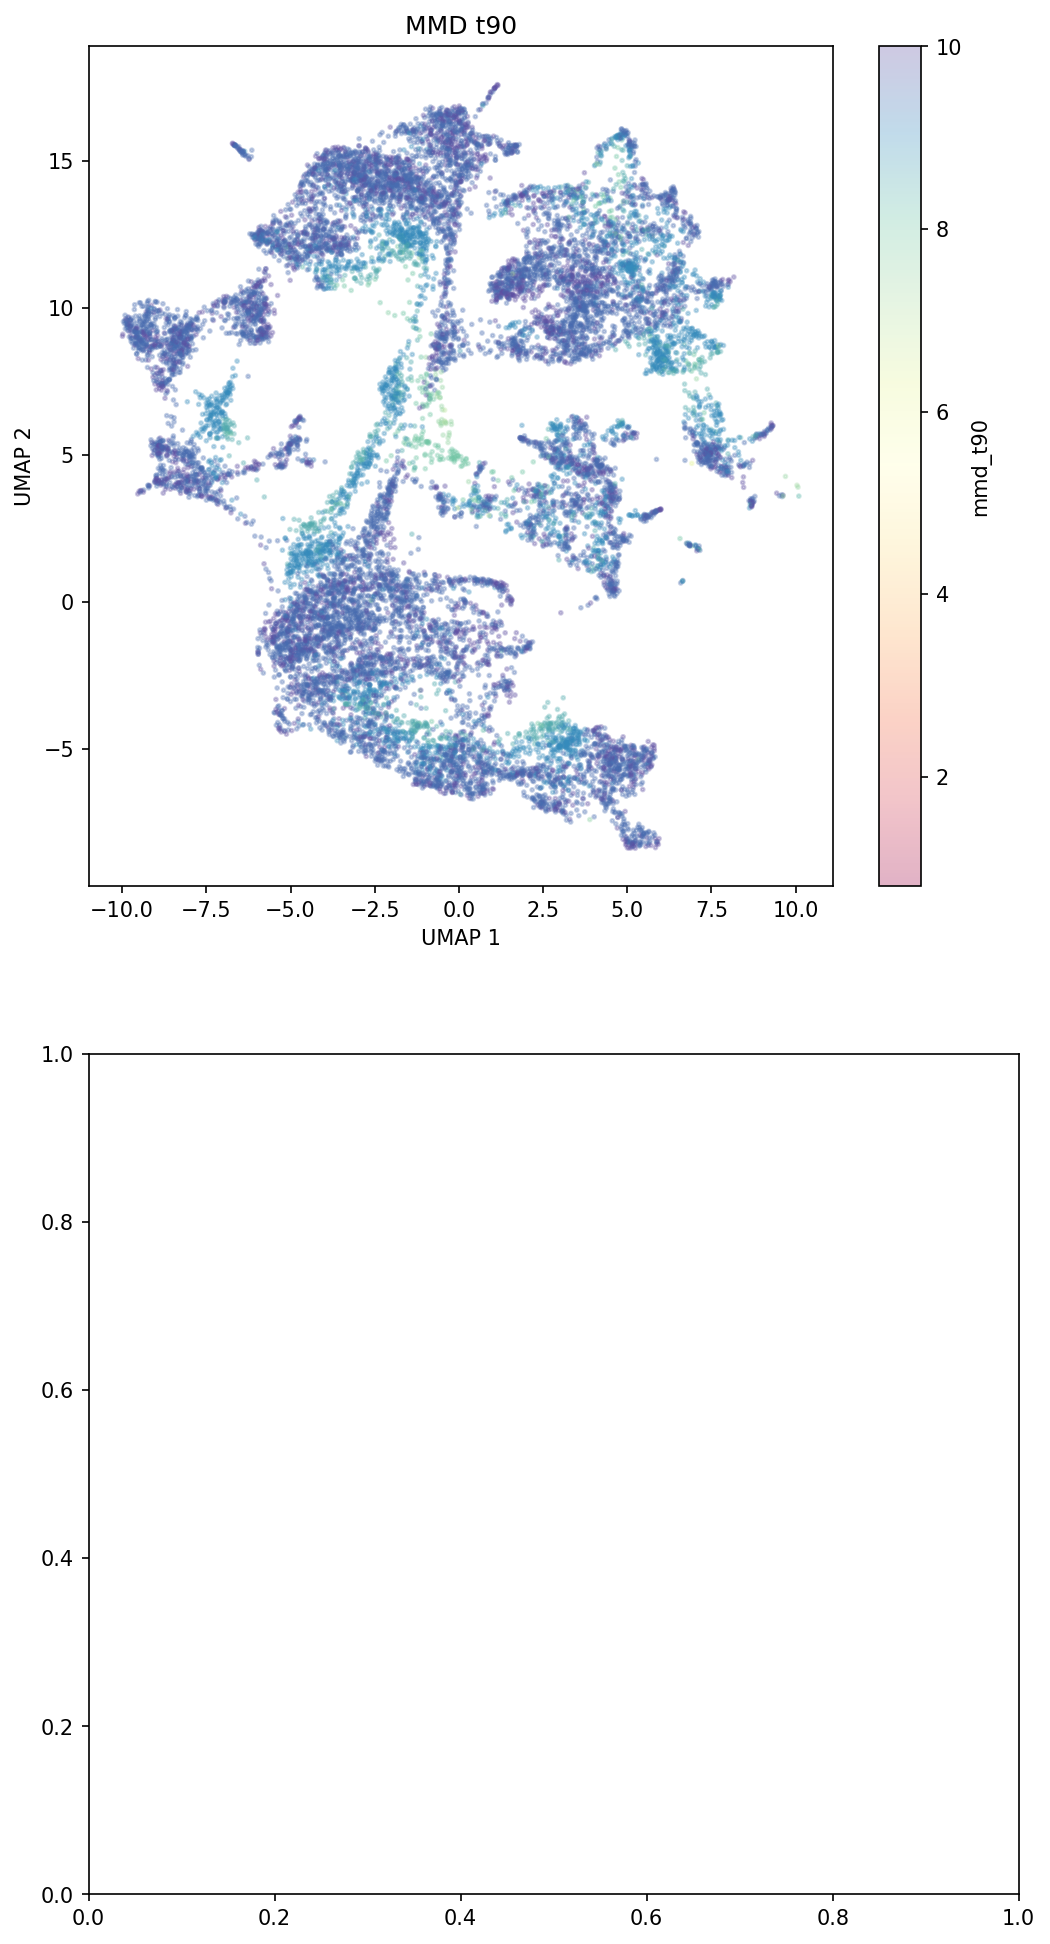

In [11]:
# Create subsampled dataset
np.random.seed(42)
n_subsample = 2*10**4
subsample_idx = np.random.choice(adata.n_obs, min(n_subsample, adata.n_obs), replace=False)
adata_subsample = adata[subsample_idx, :].copy()

sc.pp.neighbors(adata_subsample, use_rep='X_scvi')
sc.tl.umap(adata_subsample)

# Create figure with two subplots
fig, axes = plt.subplots(2, 1, figsize=(8, 16), dpi=150)

# Subplot 1: MMD values with colorbar
scatter1 = axes[0].scatter(
    adata_subsample.obsm['X_umap'][:,0],
    adata_subsample.obsm['X_umap'][:,1],
    c=adata_subsample.obs['mmd_t90'],
    s=3,
    alpha=0.3,
    cmap="Spectral",
    vmin=0.8, 
    # vmax=1
)
axes[0].set_xlabel('UMAP 1')
axes[0].set_ylabel('UMAP 2')
axes[0].set_title('MMD t90')
cbar = plt.colorbar(scatter1, ax=axes[0])
cbar.set_label('mmd_t90')

cell_types = adata_subsample.obs['cell_type']
unique_types = cell_types.unique()
colors = sns.color_palette('tab20', n_colors=len(unique_types))
color_map = dict(zip(unique_types, colors))

for ct in unique_types:
    mask = cell_types == ct
    axes[1].scatter(
        adata_subsample.obsm['X_umap'][mask, 0],
        adata_subsample.obsm['X_umap'][mask, 1],
        c=[color_map[ct]],
        s=3,
        alpha=0.3,
        label=ct
    )

axes[1].set_xlabel('UMAP 1')
axes[1].set_ylabel('UMAP 2')
axes[1].set_title('Cell Type')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=3, frameon=False)

# plt.tight_layout()
plt.show()